## Visualize Cell Types (CT) by Cell Type Annotation Tool (CTann)

Here, we build the histogram below for **private** pancreas data out of GTEx.

![](images/goal_vis.png)

## Install and import libraries

In [25]:
%pip install requests pandas seaborn matplotlib

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Load data

In [31]:
# Make sure the data folder is present
folder_path = 'data'
file_name = 'gtex-private-cell-instances.csv.gz' # note that this is private data and not commited in this repo

if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Folder '{folder_path}' created.")
else:
    print(f"Folder '{folder_path}' already exists.")

# Define the path to the file. 
file_path = f'{folder_path}/{file_name}'

Folder 'data' already exists.


## Preprocess data

In [27]:
dtype_dict = {
    'organ': 'str',
    'tool': 'category',
    'cell': 'str',
    'confidence_score': 'float32'
}

df = pd.read_csv(
  file_path, 
  compression='gzip',
  dtype=dtype_dict, 
  usecols=dtype_dict.keys()
  )
df

,organ,tool,cell,confidence_score
0,UBERON:0001264,azimuth,AAACAGCCAGCACGTT-1-1JKYN,0.747197
1,UBERON:0001264,azimuth,AAACAGCCAGGACCTT-1-1JKYN,0.862035
2,UBERON:0001264,azimuth,AAACAGCCAGGCGATA-1-1JKYN,0.797622
3,UBERON:0001264,azimuth,AAACAGCCATGGTTAT-1-1JKYN,0.857463
4,UBERON:0001264,azimuth,AAACAGCCATTGCGTA-1-1JKYN,0.630241
...,...,...,...,...
48254,UBERON:0001264,popv,TTTGTGGCAAGGTCCT-1-1LVAN,1.000000
48255,UBERON:0001264,popv,TTTGTTGGTATTTGGG-1-1LVAN,1.000000
48256,UBERON:0001264,popv,TTTGTTGGTGCAATGC-1-1LVAN,0.833333
48257,UBERON:0001264,popv,TTTGTTGGTTACGCAA-1-1LVAN,1.000000


In [28]:
df['tool'] = df['tool'].astype('category')

df_filtered = df[df['tool'] != 'panhuman']
df_filtered['tool'] = df_filtered['tool'].cat.remove_unused_categories()
# df_filtered = df
df_filtered

,organ,tool,cell,confidence_score
0,UBERON:0001264,azimuth,AAACAGCCAGCACGTT-1-1JKYN,0.747197
1,UBERON:0001264,azimuth,AAACAGCCAGGACCTT-1-1JKYN,0.862035
2,UBERON:0001264,azimuth,AAACAGCCAGGCGATA-1-1JKYN,0.797622
3,UBERON:0001264,azimuth,AAACAGCCATGGTTAT-1-1JKYN,0.857463
4,UBERON:0001264,azimuth,AAACAGCCATTGCGTA-1-1JKYN,0.630241
...,...,...,...,...
48254,UBERON:0001264,popv,TTTGTGGCAAGGTCCT-1-1LVAN,1.000000
48255,UBERON:0001264,popv,TTTGTTGGTATTTGGG-1-1LVAN,1.000000
48256,UBERON:0001264,popv,TTTGTTGGTGCAATGC-1-1LVAN,0.833333
48257,UBERON:0001264,popv,TTTGTTGGTTACGCAA-1-1LVAN,1.000000


## Visualize

In [29]:
sns.set_theme(rc={'figure.figsize': (16,8)})

plt.rcParams.update({'font.size': 14,  # Controls default text size
                     'axes.labelsize': 12,  # Controls axes label size
                     'xtick.labelsize': 10,  # Controls x-axis tick label size
                     'ytick.labelsize': 10,  # Controls y-axis tick label size
                     'legend.fontsize': 12})  # Controls legend font size

Text(0, 0.5, '# of Cells')

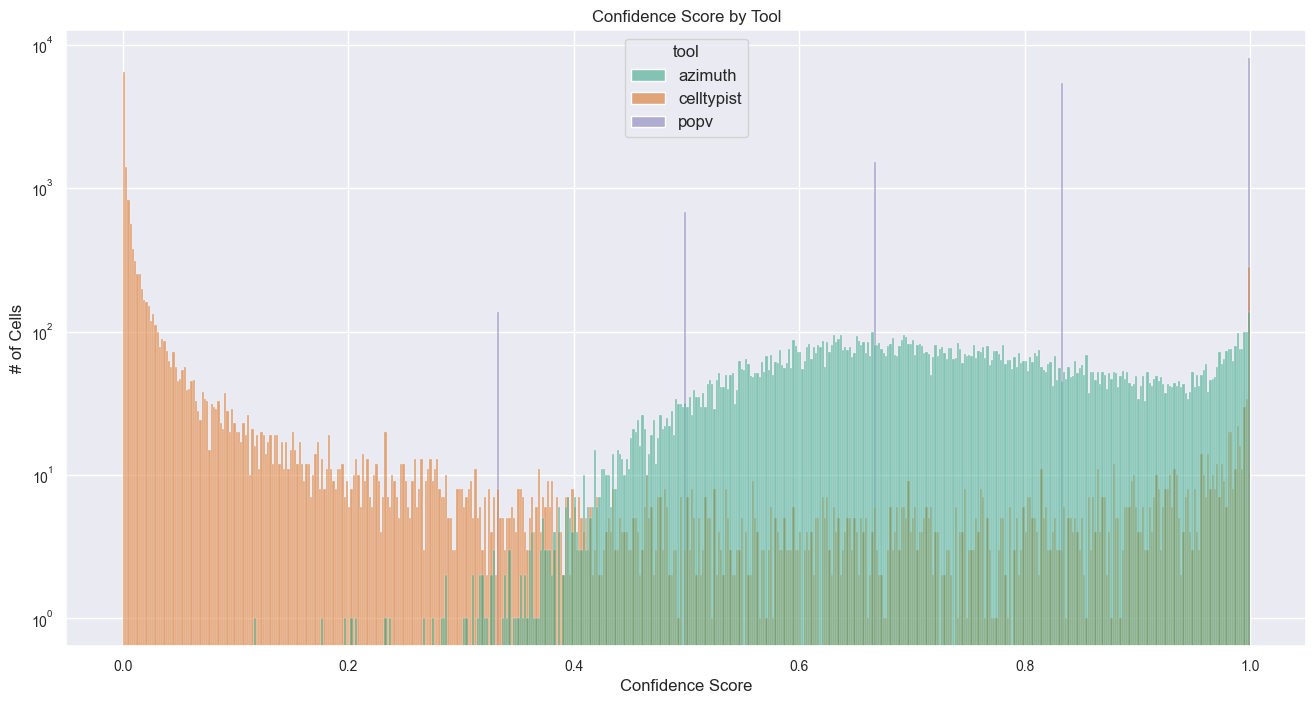

In [30]:
# make plot
g = sns.histplot(
  data=df_filtered, 
  x="confidence_score",
  binwidth=.002, 
  hue='tool',
  palette="Dark2"
  )

# Set the style to white
sns.set_style('white')

# adjust scales
plt.yscale('log')

# adjust labels++
plt.title('Confidence Score by Tool')
plt.xlabel('Confidence Score')
plt.ylabel('# of Cells')